In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.special import expit
from scipy.stats import logistic
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from sps_common.constants import DM_CONSTANT, FREQ_BOTTOM, FREQ_TOP, TSAMP
from ps_processes.processes.ps_inject import gaussian
from astropy.coordinates import SkyCoord 
from astropy import units as u
import statsmodels.api as sm

In [4]:
f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
predicted_sigma_idx = 8
output_sigma_idx = 10

data = np.unique(np.loadtxt('homogeneous_injections.txt'), axis = 0)
print(len(data))

44835


In [105]:
days = np.unique(data[:, 2])
p_total = []
RFI_mask = (data[:, S_idx] < 1e-1) & (data[:, -1] > 0)
fglob_mask = (data[:, f_idx] > 0.1) & (data[:, f_idx] < 250.)
DMglob_mask = (data[:, DM_idx] > 1.) & (data[:, DM_idx] < 400.)
DM_good_mask = (np.abs(data[:, 5] - data[:, -1]) <= 1.) | (data[:, -1] < 0)
FWHMglob_mask = (data[:, FWHM_idx] > 0.006) & (data[:, FWHM_idx] < 0.046)
glob_mask = fglob_mask & DMglob_mask & FWHMglob_mask & DM_good_mask 
data_glob = data[glob_mask & ~RFI_mask]

for i in range(len(days)):
    day_mask = data_glob[:, 2] == days[i]
    success_mask = data_glob[:, -1] > 0.
    p = len(data_glob[day_mask & success_mask]) / len(data_glob[day_mask])
    print(f'{int(days[i])}-day stack: {len(data_glob[day_mask])} injections, p({int(days[i])}) = {p:.2f}')
    p_total.append(p)

1-day stack: 1757 injections, p(1) = 0.30
4-day stack: 1593 injections, p(4) = 0.37
7-day stack: 1782 injections, p(7) = 0.36
10-day stack: 1733 injections, p(10) = 0.36
13-day stack: 1684 injections, p(13) = 0.39
16-day stack: 1635 injections, p(16) = 0.37
19-day stack: 1585 injections, p(19) = 0.39
22-day stack: 1399 injections, p(22) = 0.40
25-day stack: 1477 injections, p(25) = 0.40
28-day stack: 1278 injections, p(28) = 0.41
31-day stack: 1161 injections, p(31) = 0.39
34-day stack: 1156 injections, p(34) = 0.39
37-day stack: 1089 injections, p(37) = 0.42
40-day stack: 1020 injections, p(40) = 0.38
43-day stack: 848 injections, p(43) = 0.40
46-day stack: 803 injections, p(46) = 0.40
49-day stack: 557 injections, p(49) = 0.39
52-day stack: 307 injections, p(52) = 0.40
55-day stack: 199 injections, p(55) = 0.45
58-day stack: 12 injections, p(58) = 0.58
61-day stack: 9 injections, p(61) = 0.44


Text(0, 0.5, 'p(N)')

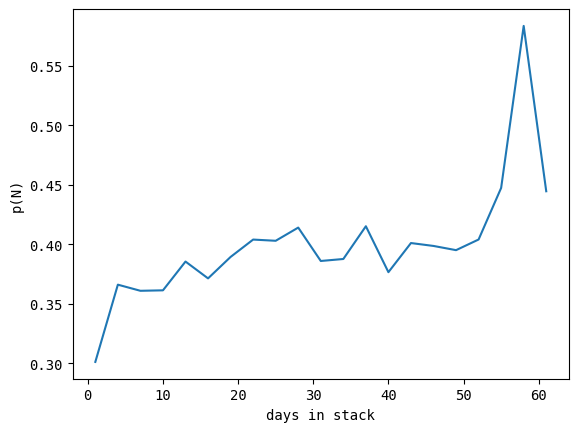

In [95]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

In [ ]:
# def get_cross_point(S, y):

#     X = sm.add_constant(S)
#     model = sm.Logit(y, X).fit()
#     param_samples = np.random.multivariate_normal(model.params, 
#                                                   model.cov_params(), 
#                                                   size=10000)

#     s0_samples = -param_samples[:, 0] / param_samples[:, 1]

#     s0_fit = s0_samples.mean()
#     s0_err = s0_samples.std()
#     print(f"S at P=0.5: {s0_fit:.4f} ± {s0_err:.4f}")

#     b0, b1 = model.params
#     def cdf_fit(s):
#         s = np.asarray(s)
#         return 1 / (1 + np.exp(-(b0 + b1 * s)))

#     return s0_fit, s0_err, cdf_fit

def get_cross_point(S, y):
    S = np.asarray(S, dtype=float)
    y = np.asarray(y, dtype=float)
 
    logS = np.log(S)
    X = sm.add_constant(logS)
    model = sm.Logit(y, X).fit()
 
    param_samples = np.random.multivariate_normal(model.params,
                                                    model.cov_params(),
                                                    size=10000)

    logS0_samples = -param_samples[:, 0] / param_samples[:, 1]
    s0_samples = np.exp(logS0_samples)
    s0_fit = s0_samples.mean()
    s0_err = s0_samples.std()
    print(f"S at P=0.5: {s0_fit:.4f} ± {s0_err:.4f}")
 
    b0, b1 = model.params
 
    def cdf_fit(s):
        s = np.asarray(s, dtype=float)
        return 1 / (1 + np.exp(-(b0 + b1 * np.log(s))))
 
    return s0_fit, s0_err, cdf_fit

def bootstrap(S, y, n_boot = 10000):

    s0_boot = []

    for _ in range(n_boot):
        idx = np.random.choice(len(S), size=len(S), replace=True)
        S_boot, y_boot = S[idx], y[idx]
        
        X_boot = sm.add_constant(S_boot)
        model_boot = sm.Logit(y_boot, X_boot).fit(disp=False)
        
        intercept, slope = model_boot.params
        s0_boot.append(-intercept / slope)

    s0_err = np.std(s0_boot)
    print(f"S at P=0.5: {np.mean(s0_boot):.4f} ± {s0_err:.4f}")

    return np.mean(s0_boot), s0_err

In [97]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_hot = np.zeros(len(days))
S_cold = np.zeros(len(days))

S_hot_err = np.zeros(len(days))
S_cold_err = np.zeros(len(days))

def logistic_4p(s, k, s0, upper):
    return expit(k * (s - s0)) * upper


for i in range(len(days)):

    day_mask = data_glob[:, 2] == days[i]
    datum = data_glob[day_mask]

    coords = SkyCoord(ra=datum[:, 0]*u.deg, dec=datum[:, 1]*u.deg, frame='icrs')
    galactic_lat = coords.galactic.b
    low_b_mask = np.abs(galactic_lat) < 10*u.degree
    high_b_mask = np.abs(galactic_lat) > 10*u.degree 
    
    print(f'Hot {days[i]}-day stack: {len(datum[low_b_mask])} samples.')
    print(f'Cold {days[i]}-day stack: {len(datum[high_b_mask])} samples.')

    S = datum[:, S_idx] 
    y = (datum[:, -1] > 0.).astype(int)
    
    if len(datum[low_b_mask]) > 400:
        
        s0_fit, s0_err = bootstrap(S[low_b_mask], y[low_b_mask])
        S_hot[i] = s0_fit
        S_hot_err[i] = s0_err
    
    else: 
        S_hot[i] = np.nan
        S_hot_err[i] = np.nan
    
    if len(datum[high_b_mask]) > 400:

        s0_fit, s0_err = bootstrap(S[high_b_mask], y[high_b_mask])
        S_cold[i] = s0_fit
        S_cold_err[i] = s0_err

    else:
        S_cold[i] = np.nan
        S_cold_err[i] = np.nan
    # fig, ax = plt.subplots()
    # ax.scatter(data[i][low_b_mask, S_idx], y_hot, s = 0.1, color = 'r', alpha=0.1)
    # ax.plot(S_range, y_pred_hot, color="red", label="Hot")
    # ax.plot(S_hot[i], 0.5, 'y*')
    # ax.scatter(data[i][high_b_mask, S_idx], y_cold, s = 0.1, color = 'b', alpha=0.1)
    # ax.plot(S_range, y_pred_cold, color="blue", label="Cold")
    # ax.plot(S_cold[i], 0.5, 'y*')
    # ax.set_xlabel("S")
    # ax.set_ylabel("P")
    # ax.set_xscale('log')
    # ax.legend()
    # plt.show()





Hot 1.0-day stack: 594 samples.
Cold 1.0-day stack: 1163 samples.
S at P=0.5: 1.1421 ± 0.1352
S at P=0.5: 0.7090 ± 0.0672
Hot 4.0-day stack: 518 samples.
Cold 4.0-day stack: 1075 samples.
S at P=0.5: 0.6411 ± 0.0768
S at P=0.5: 0.4526 ± 0.0525
Hot 7.0-day stack: 619 samples.
Cold 7.0-day stack: 1163 samples.
S at P=0.5: 0.6750 ± 0.1021
S at P=0.5: 0.5282 ± 0.1014
Hot 10.0-day stack: 606 samples.
Cold 10.0-day stack: 1127 samples.
S at P=0.5: 0.6080 ± 0.0933
S at P=0.5: 0.4936 ± 0.0727
Hot 13.0-day stack: 578 samples.
Cold 13.0-day stack: 1106 samples.
S at P=0.5: 0.7225 ± 0.1540
S at P=0.5: 0.5918 ± 0.1244
Hot 16.0-day stack: 544 samples.
Cold 16.0-day stack: 1091 samples.
S at P=0.5: 0.9112 ± 0.2103
S at P=0.5: 0.4202 ± 0.1036
Hot 19.0-day stack: 530 samples.
Cold 19.0-day stack: 1055 samples.
S at P=0.5: 0.7173 ± 0.1720
S at P=0.5: 0.3021 ± 0.0372
Hot 22.0-day stack: 458 samples.
Cold 22.0-day stack: 941 samples.
S at P=0.5: 0.8991 ± 0.1937
S at P=0.5: 0.4321 ± 0.0998
Hot 25.0-day st

Lorimer & Kramer:
$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \text{SNR} $$

where $\delta$ is the effective width.

Assuming that we will find >50% of everything with SNR > 10, and choosing $b = 0^{\circ}$ and $l = 90^{\circ}$:

In [98]:
GAIN = 1.16e-3  # K mJy^-1
TSYS = 50  # K
BETA = 1.1
NPOL = 2
TAU = 20* 10 * 60 #s
F_NYQUIST = 508 #Hz
BANDWIDTH = 400e6 #Hz

#envelope functions:
def get_nchans(maxdm):
    """
    Inputs a pointing dict with ra, dec, maxdm and returns nchans.

    Inputs
    pointing - A dict of ra, dec, maxdm
    """
    if maxdm <= 212.5:
        nchans = 1024
    elif maxdm <= 425:
        nchans = 2048
    elif maxdm <= 850:
        nchans = 4096
    elif maxdm <= 1700:
        nchans = 8192
    else:
        nchans = 16384
    return nchans


def get_dedispersion_time():

    #max DM offset we can have for channelization of 0.1 pcc
    delta_DM = 0.05 #pc / cm^-3 
    
    dt = DM_CONSTANT * delta_DM * (1/FREQ_BOTTOM**2 - 1/FREQ_TOP**2)
    
    return dt

def time_windowing(prof_fft, f):
    # apply Van der Klis Eq 2.19 for time-bin windowing effect
    harmonic_freqs = np.arange(1, len(prof_fft) + 1) * f
    B = np.sinc(harmonic_freqs * TSAMP)
    prof_fft *= B

    return prof_fft

def get_intrachannel_time(DM, maxDM):
        
    nchan = get_nchans(maxDM)

    quadratic_terms = {
            "1024": 1e-8,
            "2048": 6e-9,
            "4096": 3e-9,
            "8192": 1.5e-9,
            "16384": 8e-10,
        }
    quadratic_term = quadratic_terms[str(nchan)]

    t_intrachannel = DM * DM_CONSTANT * quadratic_term
    
    return t_intrachannel

def radiometer(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    FWHM /= f #in s
    tau = Ndays * 10 * 60 #days x minutes / day x seconds / minute
 
    t_dedisp = get_dedispersion_time() #in s
    t_intrach = get_intrachannel_time(DM, maxDM)
    
    FWHM = np.sqrt(FWHM**2 + t_dedisp**2 )
    FWHM = np.sqrt(FWHM**2 + t_intrach**2)
    FWHM = np.sqrt(FWHM**2 + TSAMP**2)

    system_terms =  BETA * (TSYS + Tsky) / GAIN
    obs_terms = 1 / np.sqrt(NPOL * tau * (BANDWIDTH / 2)) #for rfi...
    pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM)) 

    return system_terms * obs_terms * pulse_terms * SNR

def get_Scurve(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    Smin = np.zeros((len(DM), len(f)))

    for k in range(len(DM)):
        for l in range(len(f)):
            S_temp = radiometer(f[l], DM[k], SNR, FWHM, maxDM, Tsky, Ndays)
            Smin[k, l] = S_temp

    return Smin


In [99]:
def power_law(x, A, alpha):

    return A * x**alpha

# par_hot = curve_fit(power_law, days, S_hot, p0 = (1, -0.5))
# par_cold = curve_fit(power_law, days, S_cold, p0 = (1, -0.5))

# print(f'alpha_hot = {par_hot[0][1]:.2f}')
# print(f'alpha_cold = {par_cold[0][1]:.2f}')

In [100]:
many_days = np.linspace(0.2, 58)
Smin_hot_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_hot_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_cold_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 
Smin_cold_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 

(0.017453642746568607, 13.121371734219267)

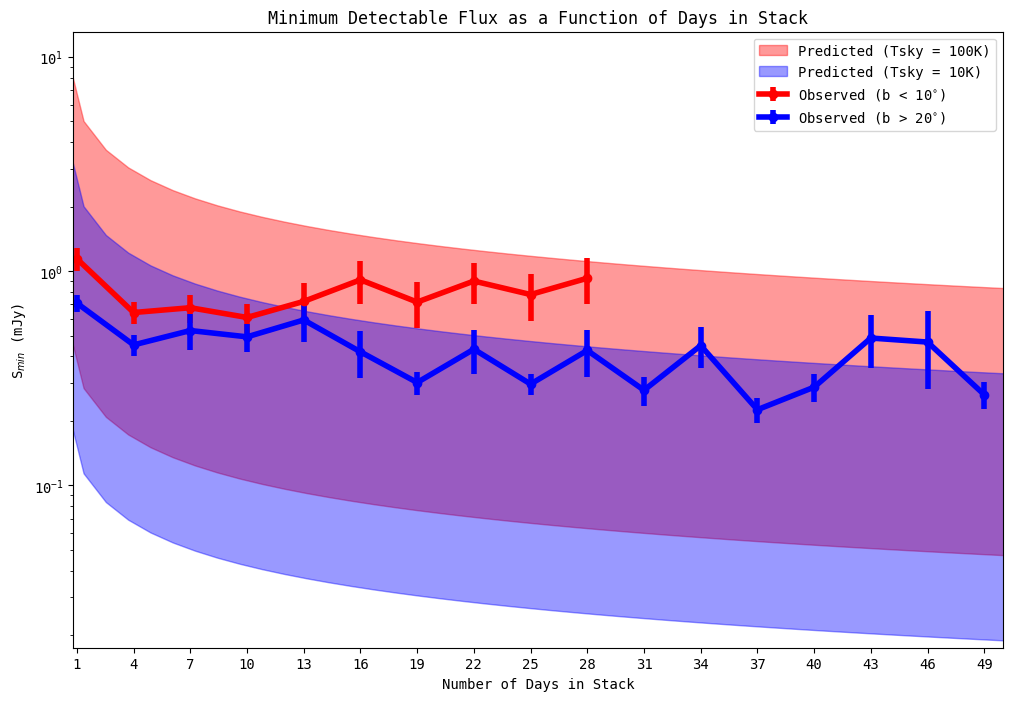

In [101]:

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
ymax = max(Smin_hot_fast)

mask_hot = np.isfinite(Smin_hot_fast)
mask_cold = np.isfinite(Smin_cold_fast)

upper_hot = np.where(mask_hot, Smin_hot_fast, ymax)
upper_cold = np.where(mask_cold, Smin_cold_fast, ymax)

hot_nanmask = np.isnan(S_hot) 
cold_nanmask = np.isnan(S_cold)

ax.fill_between(many_days, Smin_hot_mid, Smin_hot_fast,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(many_days, Smin_cold_mid, Smin_cold_fast,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')
# ax.plot(days[~hot_nanmask], S_hot[~hot_nanmask], 'r', marker = 'o', linewidth = '4.0', 
#         label = r'Observed (b < 10$^{\circ}$)')
# ax.plot(days[~cold_nanmask], S_cold[~cold_nanmask], 'b', marker = 'o', linewidth = '4.0', 
#         label = r'Observed (b > 20$^{\circ}$)')
ax.errorbar(days[~hot_nanmask], S_hot[~hot_nanmask], yerr = S_hot_err[~hot_nanmask], 
            color = 'r', marker = 'o', linewidth = 4., 
         label = r'Observed (b < 10$^{\circ}$)')
ax.errorbar(days[~cold_nanmask], S_cold[~cold_nanmask], yerr = S_cold_err[~cold_nanmask], 
            color = 'b', marker = 'o', linewidth = 4., 
         label = r'Observed (b > 20$^{\circ}$)')
# ax.errorbar(days[~hot_nanmask], S_hot_pred[~hot_nanmask], yerr = S_hot_err_pred[~hot_nanmask], 
#             color = 'r', marker = 'o', linewidth = 4., linestyle = ':',
#          label = r'Predicted (b < 10$^{\circ}$)')
# ax.errorbar(days[~cold_nanmask], S_cold_pred[~cold_nanmask], yerr = S_cold_err_pred[~cold_nanmask], 
#             color = 'b', marker = 'o', linewidth = 4., linestyle = ':',
#          label = r'Predicted (b > 20$^{\circ}$)')
# ax.plot(many_days, power_law(many_days, S_hot[0], -0.5), 'r--', linewidth = '2.0',
#         label = r'$S_{min} \propto N^{-\frac{1}{2}}$')
# ax.plot(many_days, power_law(many_days, S_cold[0], -0.5), 'b--', linewidth = '2.0', 
#         label = r'$S_{min} \propto N^{-\frac{1}{2}}$')


# ax.set_xlim(np.nanmin(many_days), np.nanmax(many_days))
# ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

ax.legend()
ax.set_xticks(range(1, 52, 3))
ax.set_xlabel('Number of Days in Stack')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.set_yscale('log')
ax.set_title('Minimum Detectable Flux as a Function of Days in Stack')
ax.set_xlim(0.8, 50)
ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

Below is a really complicated way of sorting all our data into chunks based off the channelization.

In [553]:
all_data = np.concatenate(data_unglob, axis = 0)
coords = SkyCoord(ra=all_data[:, 0]*u.deg, dec=all_data[:, 1]*u.deg, frame='icrs')
galactic_lat = coords.galactic.b
low_b_mask = np.abs(galactic_lat) < 5*u.degree
high_b_mask = np.abs(galactic_lat) > 10*u.degree 

f_bins = np.logspace(np.log10(0.05), np.log10(250), 500)
f_dev = 50
S_bins = np.logspace(-2, 1, 500)
S_dev = 50

Smin_of_f = np.zeros((4, len(f_bins) - 1))
FWHM_lazarus_mask = (all_data[:, FWHM_idx] > 0.014) & (all_data[:, FWHM_idx] < 0.034)
DM_mask = (all_data[:, DM_idx] > 1.) 
length_mask = all_data[:, 2] == 14

print(f'Analyzing {len(all_data[FWHM_lazarus_mask & DM_mask & length_mask & low_b_mask])} low-b injections.')
print(f'Analyzing {len(all_data[FWHM_lazarus_mask & DM_mask & length_mask & high_b_mask])} high-b injections.')

'''
_____________________
HOT SKY
'''
_, f_S_unsmooth_hot, f_S_smooth_hot = au.get_sensitivity(
    all_data[FWHM_lazarus_mask & DM_mask & low_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[0, j] = np.min(S_bins[np.where(f_S_smooth_hot[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

'''
_____________________
COLD SKY
'''
_, f_S_unsmooth_cold, f_S_smooth_cold = au.get_sensitivity(
    all_data[FWHM_lazarus_mask & DM_mask & high_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[1, j] = np.min(S_bins[np.where(f_S_smooth_cold[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

Smin_of_f[0] = gaussian_filter(Smin_of_f[0], 5)
Smin_of_f[1] = gaussian_filter(Smin_of_f[1], 5)


predicted_Smin_of_f = np.zeros((4, len(f_bins) - 1))
#shape is:
#hot sky, max DM 
#cold sky, max DM 
#hot sky, min DM 
#cold sky, min DM
predicted_Smin_of_f[0] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[1] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)
predicted_Smin_of_f[2] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[3] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)

Analyzing 359 low-b injections.
Analyzing 7432 high-b injections.


/tmp/ipykernel_2130863/215501640.py:78: RuntimeWarning: invalid value encountered in sqrt
  pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM))


Text(0.5, 1.0, 'Minimum Detectable Flux for 2 Week Stacks')

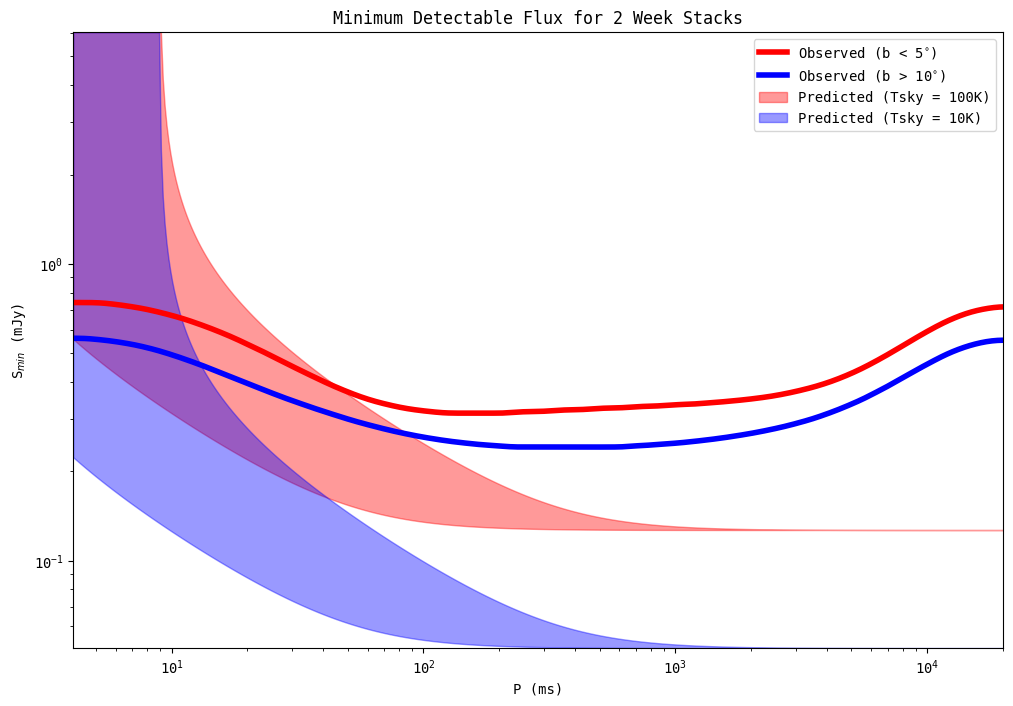

In [554]:
P = 1/f_bins[:-1]
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.plot(P*1e3, Smin_of_f[0], 'r', linewidth=4.0, label=r'Observed (b < 5$^{\circ}$)')
ax.plot(P*1e3, Smin_of_f[1], 'b', linewidth=4.0, label=r'Observed (b > 10$^{\circ}$)')

ax.loglog()
ymax = max(predicted_Smin_of_f[0])

mask_hot = np.isfinite(predicted_Smin_of_f[0])
mask_cold = np.isfinite(predicted_Smin_of_f[1])

upper_hot = np.where(mask_hot, predicted_Smin_of_f[0], ymax)
upper_cold = np.where(mask_cold, predicted_Smin_of_f[1], ymax)

ax.fill_between(P*1e3, predicted_Smin_of_f[2], upper_hot,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(P*1e3, predicted_Smin_of_f[3], upper_cold,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')

ax.set_xlabel('P (ms)')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.legend()
ax.set_xlim(min(P*1e3), max(P*1e3))
ax.set_ylim(min(predicted_Smin_of_f[3]), max(predicted_Smin_of_f[0]))
ax.set_title('Minimum Detectable Flux for 2 Week Stacks')

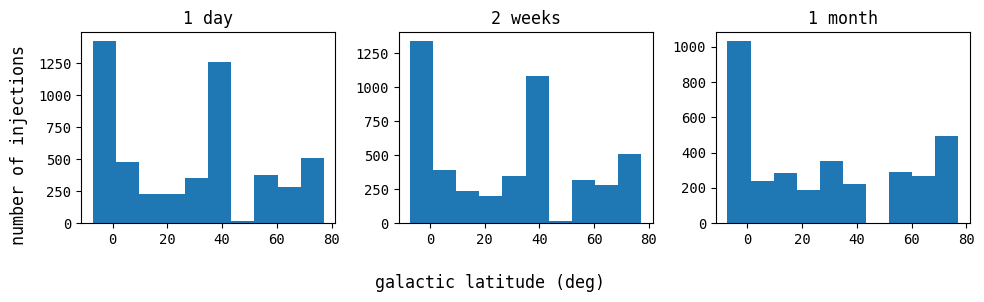

In [ ]:
mask_1 = data[:, 2] == 1.
coords = SkyCoord(ra=data[mask_1, 0]*u.deg, dec=data[mask_1, 1]*u.deg, frame='icrs')
b_1= coords.galactic.b

mask_16 = data[:, 2] == 16.
coords = SkyCoord(ra=data[mask_16, 0]*u.deg, dec=data[mask_16, 1]*u.deg, frame='icrs')
b_16 = coords.galactic.b

mask_31 = data[:, 2] ==  31.
coords = SkyCoord(ra=data[mask_31, 0]*u.deg, dec=data[mask_31, 1]*u.deg, frame='icrs')
b_31 = coords.galactic.b

counts_1, bins_1 = np.histogram(b_1)
counts_16, bins_16 = np.histogram(b_16)
counts_31, bins_31 = np.histogram(b_31)

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_16[:-1], bins_16, weights=counts_16)
ax[2].hist(bins_31[:-1], bins_31, weights=counts_31)

fig.supxlabel('galactic latitude (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()

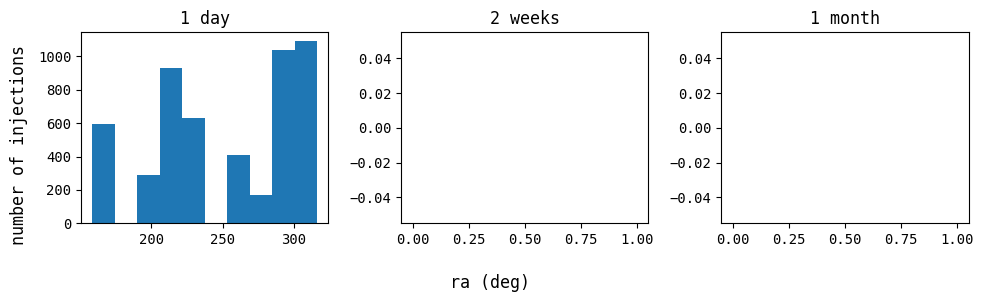

In [ ]:
counts_1, bins_1 = np.histogram(data[mask_1, 0])
counts_16, bins_16 = np.histogram(data[mask_16, 0])
counts_31, bins_31 = np.histogram(data[mask_31, 0])

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_16[:-1], bins_16, weights=counts_16)
ax[2].hist(bins_31[:-1], bins_31, weights=counts_31)

fig.supxlabel('ra (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()

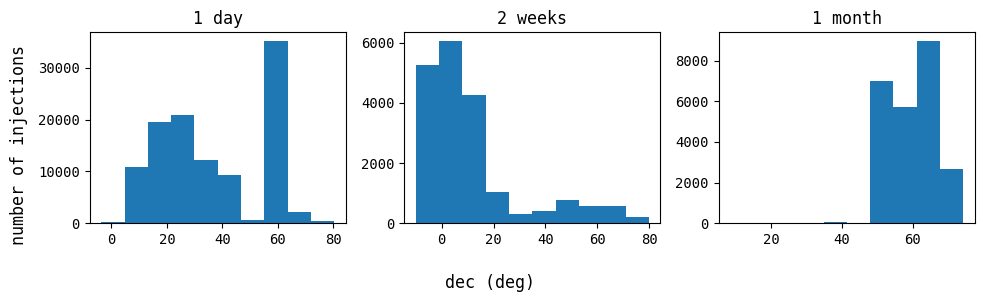

In [ ]:
counts_1, bins_1 = np.histogram(data_1[:, 1])
counts_16, bins_16 = np.histogram(data_16[:, 1])
counts_31, bins_31 = np.histogram(data_31[:, 1])

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_16[:-1], bins_16, weights=counts_16)
ax[2].hist(bins_31[:-1], bins_31, weights=counts_31)

fig.supxlabel('dec (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()

In [32]:
def func_to_fit(x, a, B):

    return a * np.sqrt(x) + B

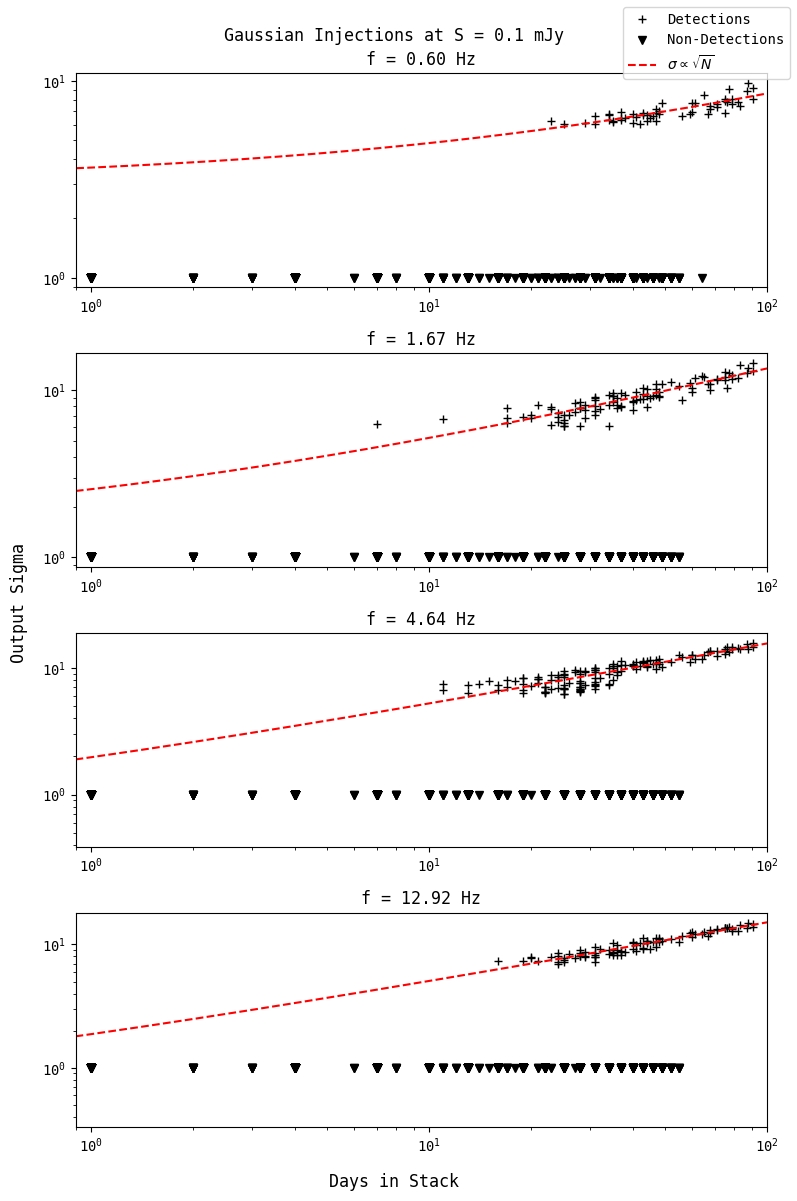

In [102]:
const_inj = np.loadtxt('constant_01mJy_injections.txt')
# dec_mask = (const_inj[:, 1] > 70) & (const_inj[:, 1] < 80)
# ra_mask = (const_inj[:, 0] > 200) & (const_inj[:, 0] < 220)
# const_inj = const_inj[dec_mask & ra_mask]

f_unique = np.unique(const_inj[:, f_idx])[4:8]

fig, ax = plt.subplots(len(f_unique), 1, figsize = (8, 12))

for i in range(len(f_unique)):
    f_mask = const_inj[:, f_idx] == f_unique[i]
    outlier_mask = const_inj[:, output_sigma_idx] > 100.
    f_data = const_inj[f_mask & ~outlier_mask]
    found_mask = f_data[:, -1] > 0

    ax[i].plot(f_data[~found_mask, 2], np.ones(len(f_data[~found_mask])),
            'v', color = 'black')
    ax[i].plot(f_data[found_mask, 2], f_data[found_mask, output_sigma_idx],
            '+', color = 'black')
    ax[i].set_title(f'f = {f_unique[i]:.2f} Hz')

    N = f_data[found_mask, 2]
    sig = f_data[found_mask, output_sigma_idx]
    min_idx = np.argmin(sig)
    max_idx = np.argmax(sig)
    a_guess = (sig[max_idx] - sig[min_idx]) / (np.sqrt(N[max_idx]) - np.sqrt(N[min_idx]))
    B_guess = sig[min_idx] - a_guess * np.sqrt(N[min_idx])

    a, B = curve_fit(func_to_fit, 
                        f_data[found_mask, 2],
                        f_data[found_mask, output_sigma_idx],
                        p0 = [a_guess, B_guess]
                        )[0]

    ax[i].plot(np.linspace(0, 100, 1000), 
        a * np.sqrt(np.linspace(0, 100, 1000)) + B,
        'r--')
    ax[i].loglog()
    # ax[i].set_xlabel('Days in Stack')
    # ax[i].set_ylabel('Output Sigma')
    ax[i].set_xlim(0.9, 100)

ax[0].plot(-1, -1, '+', color = 'black', label = 'Detections')
ax[0].plot(-1, -1, 'v', color = 'black', label = 'Non-Detections')
ax[0].plot(-1, -1, 'r--', label = r'$\sigma \propto \sqrt{N}$')

fig.legend()
fig.supxlabel('Days in Stack')
fig.supylabel('Output Sigma')
fig.suptitle('Gaussian Injections at S = 0.1 mJy')
plt.tight_layout()

1174 1174
Optimization terminated successfully.
         Current function value: 0.094258
         Iterations 11
S at P=0.5: 57.1602 ± 2.7379
1174 1174
Optimization terminated successfully.
         Current function value: 0.199716
         Iterations 9
S at P=0.5: 56.8108 ± 3.7952
1174 1174
Optimization terminated successfully.
         Current function value: 0.274137
         Iterations 8
S at P=0.5: 55.2300 ± 4.1900
1174 1174
Optimization terminated successfully.
         Current function value: 0.172911
         Iterations 9
S at P=0.5: 54.8370 ± 3.0771


/tmp/ipykernel_3008646/2919237865.py:47: RuntimeWarning: divide by zero encountered in log
  return 1 / (1 + np.exp(-(b0 + b1 * np.log(s))))


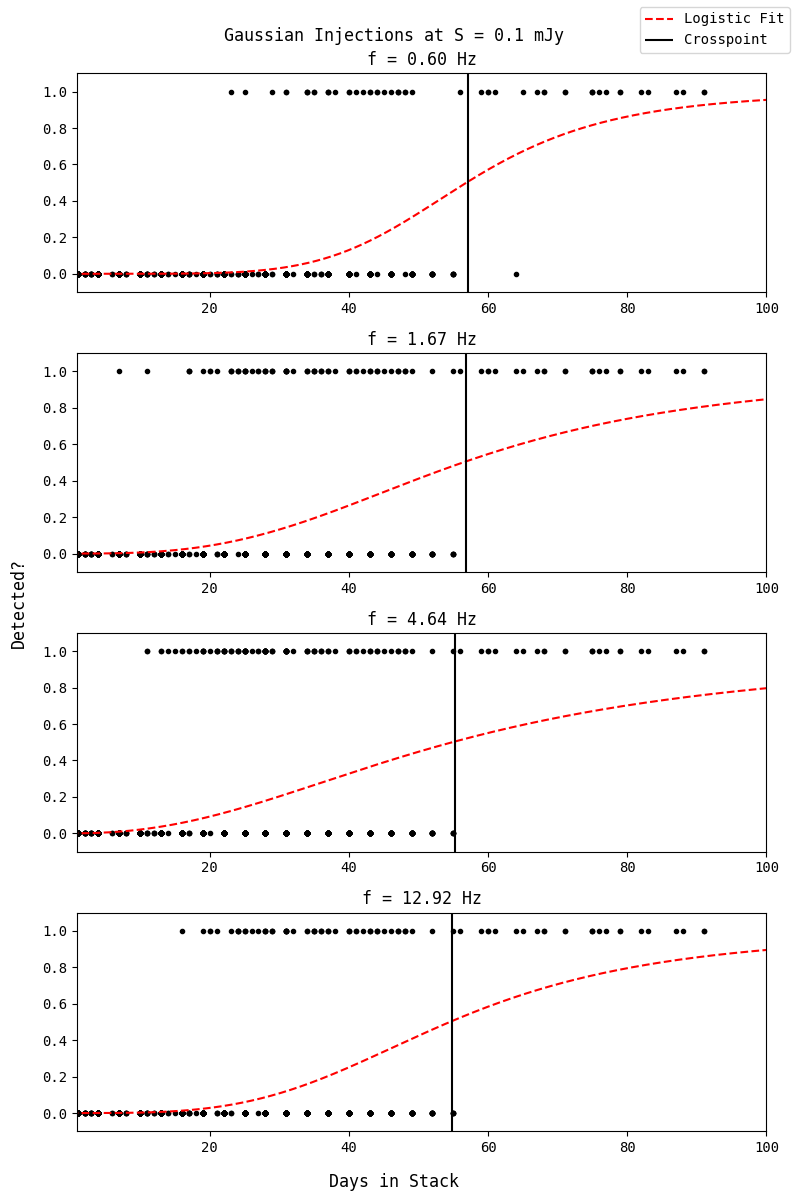

In [103]:
fig, ax = plt.subplots(len(f_unique), 1, figsize = (8, 12))

for i in range(len(f_unique)):
    f_mask = const_inj[:, f_idx] == f_unique[i]
    outlier_mask = const_inj[:, output_sigma_idx] > 100.
    f_data = const_inj[f_mask & ~outlier_mask]
    found_mask = f_data[:, -1] > 0

    N = f_data[:, 2]
    y = found_mask.astype(int)

    print(len(N), len(y))
    N_cross, _, cdf_fit = get_cross_point(N, y)
    
    ax[i].plot(f_data[:, 2], y,
            '.', color = 'black')
    ax[i].set_title(f'f = {f_unique[i]:.2f} Hz')

    x = np.linspace(0, 100, 1000)
    ax[i].plot(x, 
        cdf_fit(x),
        'r--'
        )
    ax[i].vlines(N_cross,
                 ymin = -0.1,
                 ymax = 1.1,
                 color = 'black'
                 )
    # ax[i].set_xlabel('Days in Stack')
    # ax[i].set_ylabel('Output Sigma')
    ax[i].set_xlim(0.9, 100)
    ax[i].set_ylim(-0.1, 1.1)

ax[0].plot(-1, -1, 'r--', label = 'Logistic Fit')
ax[0].vlines(-1, 0.1, 0.2, color = 'black', label = 'Crosspoint')

fig.legend()
fig.supxlabel('Days in Stack')
fig.supylabel('Detected?')
fig.suptitle('Gaussian Injections at S = 0.1 mJy')
plt.tight_layout()

Optimization terminated successfully.
         Current function value: 0.265069
         Iterations 8
S at P=0.5: 1.7328 ± 0.0921
Optimization terminated successfully.
         Current function value: 0.294583
         Iterations 8
S at P=0.5: 1.0734 ± 0.0571
Optimization terminated successfully.
         Current function value: 0.301011
         Iterations 8
S at P=0.5: 0.8853 ± 0.0468
Optimization terminated successfully.
         Current function value: 0.295083
         Iterations 8
S at P=0.5: 0.8967 ± 0.0476
Optimization terminated successfully.
         Current function value: 0.316053
         Iterations 8
S at P=0.5: 0.7847 ± 0.0434
Optimization terminated successfully.
         Current function value: 0.304648
         Iterations 8
S at P=0.5: 0.7983 ± 0.0451
Optimization terminated successfully.
         Current function value: 0.303238
         Iterations 8
S at P=0.5: 0.7392 ± 0.0419
Optimization terminated successfully.
         Current function value: 0.307173
         I

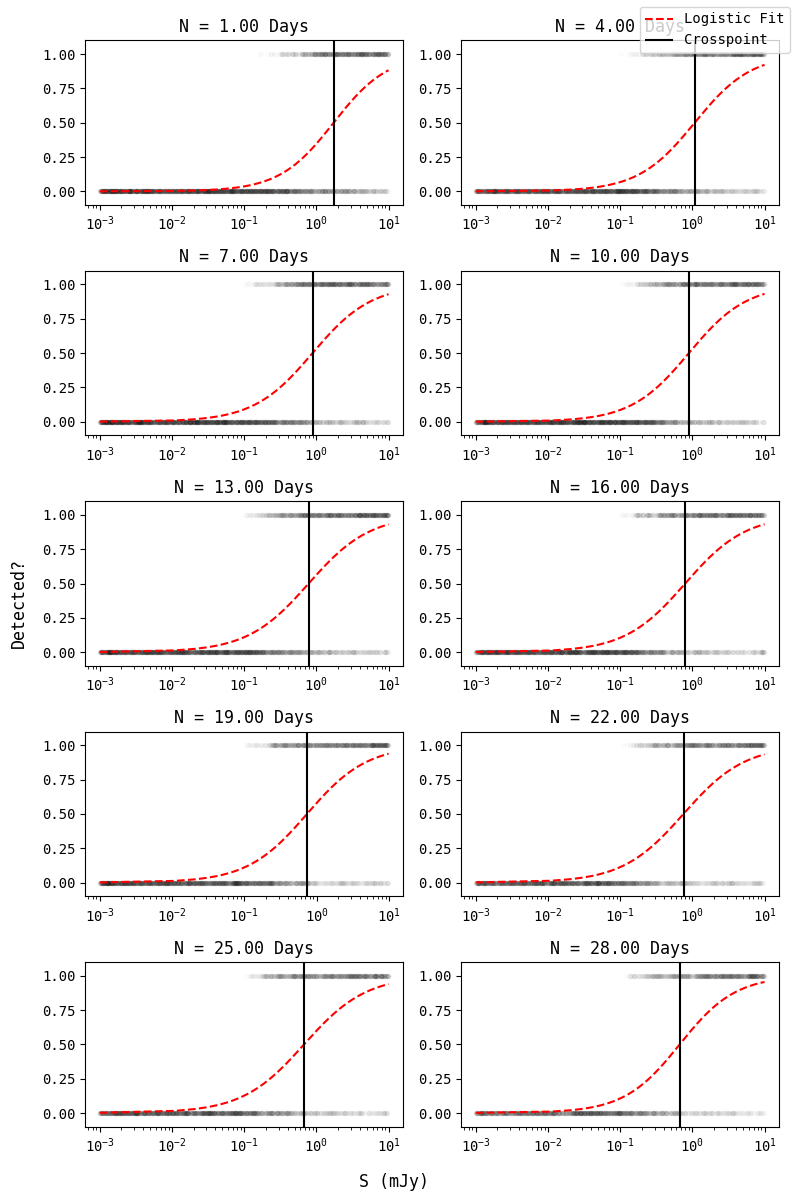

In [109]:
days = days[:10]

fig, ax = plt.subplots(5, 2, figsize = (8, 12))
ax = ax.flatten()

for i in range(len(days)):
    day_mask = data[:, 2] == days[i]
    day_data = data[day_mask & ~RFI_mask]
    found_mask = day_data[:, -1] > 0

    S = day_data[:, S_idx]
    y = found_mask.astype(int)

    S_cross, _, cdf_fit = get_cross_point(S, y)
    
    ax[i].plot(S, y,
            '.', color = 'black', alpha = 0.01)
    ax[i].set_title(f'N = {days[i]:.2f} Days')

    x = np.linspace(np.min(S), np.max(S), 1000)
    ax[i].plot(x, 
        cdf_fit(x),
        'r--'
        )
    ax[i].vlines(S_cross,
                 ymin = -0.1,
                 ymax = 1.1,
                 color = 'black'
                 )
    # ax[i].set_xlabel('Days in Stack')
    # ax[i].set_ylabel('Output Sigma')
    ax[i].set_ylim(-0.1, 1.1)
    ax[i].set_xscale('log')

ax[0].plot(-1, -1, 'r--', label = 'Logistic Fit')
ax[0].vlines(-1, 0.1, 0.2, color = 'black', label = 'Crosspoint')

fig.legend()
fig.supxlabel('S (mJy)')
fig.supylabel('Detected?')
plt.tight_layout()